<h2> Beyond Crime Counts: Socioeconomic Factors and Neighborhood Safety in Chicago </h2>
Group Member: Xinyao Ding, Christin Xu, Yike Li

<h2>1. Introduction</h2>
This project examines reported crime patterns across Chicago’s 77 community areas from 2020 to 2024 and explores how these patterns are related to neighborhood-level socioeconomic conditions. The analysis focuses on whether poverty rate, per capita income, and hardship index are associated with differences in total reported crime volume, violent crime share, domestic-related crime share, and arrest rate across neighborhoods.<br><br>

The target audience for this analysis includes city policymakers, community development organizations, and real estate analysts who need to evaluate neighborhood-level safety and socioeconomic risk in Chicago. For these users, looking only at total reported crime counts can be misleading. A neighborhood with a high number of reported incidents may reflect greater population exposure, commercial activity, reporting behavior, or deeper structural challenges. Combining crime data with socioeconomic indicators provides a more complete view of neighborhood conditions.

This project uses two public datasets from the City of Chicago Data Portal. The crime dataset contains incident-level reported crime records from 2020 to 2024, including crime type, date, arrest status, domestic indicator, community area, and geographic coordinates. The socioeconomic dataset contains community-area-level indicators, including poverty rate, per capita income, and hardship index. Because the two datasets are measured at different levels, the crime records are aggregated to the community-area level before being merged with the socioeconomic data.

This analysis is exploratory and should not be interpreted as causal. Reported crime data may reflect actual crime patterns as well as differences in reporting behavior, policing activity, or data collection practices. Similarly, socioeconomic indicators are treated as neighborhood characteristics rather than direct causes of crime. The goal is to identify meaningful patterns that can support further policy, community development, or investment analysis.

<h2>2. Data Sources and Analytical Design</h2>

This analysis uses two public datasets from the City of Chicago Data Portal. The first dataset contains incident-level reported crime records in Chicago from 2020 to 2024. Each row represents one reported crime incident and includes variables such as crime type, date, arrest status, domestic indicator, police district, ward, community area, latitude, and longitude. The second dataset contains socioeconomic indicators for Chicago’s 77 community areas, including poverty rate, per capita income, and hardship index.

Because the two datasets are measured at different levels, they must be aligned before analysis. The crime dataset is first cleaned and aggregated from the incident level to the community-area level. The socioeconomic dataset already contains one row per community area. The final analytical dataset therefore uses `community_area` as the merge key, with each row representing one Chicago community area.

The main outcome variables created from the crime data are total reported crimes, violent crime share, domestic-related crime share, and arrest rate. These measures are used together because total reported crime volume alone may not fully describe neighborhood safety conditions. For example, one community may have many reported incidents but a lower violent crime share, while another may have fewer total incidents but a more severe crime composition.

The final merged dataset allows the analysis to compare neighborhood crime profiles with socioeconomic conditions such as poverty rate, per capita income, and hardship index. This structure supports both exploratory data analysis and modeling at the community-area level.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import time

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import time

# ------------------------------------------------------------
# Load source datasets through the City of Chicago Data Portal API
# ------------------------------------------------------------

def load_socrata_dataset(base_url, params, limit=25000, sleep_time=0.2, max_pages=None):
    all_rows = []
    offset = 0
    page = 1

    while True:
        page_params = params.copy()
        page_params["$limit"] = limit
        page_params["$offset"] = offset

        print(f"Requesting page {page}, offset {offset}...", flush=True)

        response = requests.get(base_url, params=page_params, timeout=120)
        response.raise_for_status()

        rows = response.json()

        if len(rows) == 0:
            print("No more rows returned. Download complete.", flush=True)
            break

        all_rows.extend(rows)

        print(f"Downloaded {len(all_rows):,} rows so far.", flush=True)

        offset += limit
        page += 1

        if max_pages is not None and page > max_pages:
            print("Stopped early because max_pages was reached.", flush=True)
            break

        time.sleep(sleep_time)

    return pd.DataFrame(all_rows)


# ------------------------------------------------------------
# 1. Crime data: Chicago Crimes, 2020–2024
# ------------------------------------------------------------

crime_url = "https://data.cityofchicago.org/resource/ijzp-q8t2.json"

crime_params = {
    "$select": (
        "id, date, primary_type, description, location_description, "
        "arrest, domestic, beat, district, ward, community_area, latitude, longitude"
    ),
    "$where": "date >= '2020-01-01T00:00:00' AND date < '2025-01-01T00:00:00'",
    "$order": "date, id"
}

crime = load_socrata_dataset(crime_url, crime_params, limit=25000)


# Remove exact duplicate records that may appear during API pagination
crime_rows_before_dedup = len(crime)
crime = crime.drop_duplicates().copy()
crime_rows_after_dedup = len(crime)

print("Crime rows before duplicate removal:", crime_rows_before_dedup)
print("Crime rows after duplicate removal:", crime_rows_after_dedup)
print("Duplicate rows removed:", crime_rows_before_dedup - crime_rows_after_dedup)


# Make sure all expected crime columns exist
crime_expected_columns = [
    "id", "date", "primary_type", "description", "location_description",
    "arrest", "domestic", "beat", "district", "ward",
    "community_area", "latitude", "longitude"
]

for col in crime_expected_columns:
    if col not in crime.columns:
        crime[col] = np.nan

crime = crime[crime_expected_columns]


# Convert selected crime columns into expected formats
numeric_crime_columns = [
    "id", "beat", "district", "ward",
    "community_area", "latitude", "longitude"
]

for col in numeric_crime_columns:
    crime[col] = pd.to_numeric(crime[col], errors="coerce")


# Convert arrest and domestic into Boolean format
crime["arrest"] = crime["arrest"].astype(str).str.lower().map({
    "true": True,
    "false": False
})

crime["domestic"] = crime["domestic"].astype(str).str.lower().map({
    "true": True,
    "false": False
})


# ------------------------------------------------------------
# 2. Socioeconomic data: Selected socioeconomic indicators
# ------------------------------------------------------------

socio_url = "https://data.cityofchicago.org/resource/kn9c-c2s2.json"

socio_params = {
    "$select": (
        "ca, community_area_name, percent_households_below_poverty, "
        "per_capita_income_, hardship_index"
    )
}

socio_raw = load_socrata_dataset(socio_url, socio_params, limit=5000)


# Rename socioeconomic columns to match the variable names used later
socio = socio_raw.rename(columns={
    "ca": "community_area",
    "percent_households_below_poverty": "poverty_rate",
    "per_capita_income_": "per_capita_income"
})


# Make sure all expected socioeconomic columns exist
socio_expected_columns = [
    "community_area",
    "community_area_name",
    "poverty_rate",
    "per_capita_income",
    "hardship_index"
]

for col in socio_expected_columns:
    if col not in socio.columns:
        socio[col] = np.nan

socio = socio[socio_expected_columns]


# Convert socioeconomic columns into numeric formats
numeric_socio_columns = [
    "community_area",
    "poverty_rate",
    "per_capita_income",
    "hardship_index"
]

for col in numeric_socio_columns:
    socio[col] = pd.to_numeric(socio[col], errors="coerce")


# Keep only Chicago's 77 community areas
# The API includes one citywide summary row, which is not a community area
socio = socio[
    socio["community_area"].between(1, 77)
].copy()

socio["community_area"] = socio["community_area"].astype(int)


# ------------------------------------------------------------
# 3. Confirm imported dataset sizes and columns
# ------------------------------------------------------------

print("Crime dataset shape:", crime.shape)
print("Socioeconomic dataset shape:", socio.shape)

print("\nCrime columns:")
print(crime.columns.tolist())

print("\nSocioeconomic columns:")
print(socio.columns.tolist())

Requesting page 1, offset 0...
Downloaded 25,000 rows so far.
Requesting page 2, offset 25000...
Downloaded 50,000 rows so far.
Requesting page 3, offset 50000...
Downloaded 75,000 rows so far.
Requesting page 4, offset 75000...
Downloaded 100,000 rows so far.
Requesting page 5, offset 100000...
Downloaded 125,000 rows so far.
Requesting page 6, offset 125000...
Downloaded 150,000 rows so far.
Requesting page 7, offset 150000...
Downloaded 175,000 rows so far.
Requesting page 8, offset 175000...
Downloaded 200,000 rows so far.
Requesting page 9, offset 200000...
Downloaded 225,000 rows so far.
Requesting page 10, offset 225000...
Downloaded 250,000 rows so far.
Requesting page 11, offset 250000...
Downloaded 275,000 rows so far.
Requesting page 12, offset 275000...
Downloaded 300,000 rows so far.
Requesting page 13, offset 300000...
Downloaded 325,000 rows so far.
Requesting page 14, offset 325000...
Downloaded 350,000 rows so far.
Requesting page 15, offset 350000...
Downloaded 375,00

<h2>3. Data Quality Checks</h2>
This section performs initial data quality checks before cleaning, feature engineering, and modeling. The checks focus on data types, missing values, duplicate records, key identifiers, and categorical distributions. These steps help confirm whether the raw datasets are reliable enough to support community-area-level analysis.

## 3.1 Check Data Types

Data types are reviewed first to identify variables that need transformation before analysis. In particular, the crime date is stored as a string, `community_area` is stored as a numeric field with missing values, and `arrest` and `domestic` are Boolean variables. These variables will later be converted into formats suitable for aggregation, merging, and modeling.

In [5]:
crime.info()

<class 'pandas.DataFrame'>
RangeIndex: 1185019 entries, 0 to 1185018
Data columns (total 13 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1185019 non-null  int64  
 1   date                  1185019 non-null  str    
 2   primary_type          1185019 non-null  str    
 3   description           1185019 non-null  str    
 4   location_description  1178162 non-null  str    
 5   arrest                1185019 non-null  bool   
 6   domestic              1185019 non-null  bool   
 7   beat                  1185019 non-null  int64  
 8   district              1185019 non-null  int64  
 9   ward                  1184986 non-null  float64
 10  community_area        1184892 non-null  float64
 11  latitude              1164498 non-null  float64
 12  longitude             1164498 non-null  float64
dtypes: bool(2), float64(4), int64(3), str(4)
memory usage: 172.8 MB


In [6]:
socio.info()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   community_area       77 non-null     int64  
 1   community_area_name  77 non-null     str    
 2   poverty_rate         77 non-null     float64
 3   per_capita_income    77 non-null     int64  
 4   hardship_index       77 non-null     float64
dtypes: float64(2), int64(2), str(1)
memory usage: 4.0 KB


## 3.2 Missing Value Summary

In [7]:
def missing_summary(df):
    summary = (
        df.isna().sum()
        .reset_index()
        .rename(columns={"index": "column", 0: "missing_count"})
    )
    summary["missing_percent"] = summary["missing_count"] / len(df) * 100
    return summary.sort_values("missing_percent", ascending=False)

crime_missing = missing_summary(crime)
crime_missing

,column,missing_count,missing_percent
11,latitude,20521,1.731702
12,longitude,20521,1.731702
4,location_description,6857,0.578641
10,community_area,127,0.010717
9,ward,33,0.002785
3,description,0,0.000000
2,primary_type,0,0.000000
1,date,0,0.000000
0,id,0,0.000000
8,district,0,0.000000


In [8]:
socio_missing = missing_summary(socio)
socio_missing

,column,missing_count,missing_percent
0,community_area,0,0.0
1,community_area_name,0,0.0
2,poverty_rate,0,0.0
3,per_capita_income,0,0.0
4,hardship_index,0,0.0


The crime dataset has relatively low missingness overall. Latitude and longitude have the highest missing rates, at about 1.7%, but these variables are not central to the community-area-level analysis. The key merge variable, `community_area`, is missing in only 127 records, or about 0.01% of the dataset. Because `community_area` is required to aggregate and merge the crime data with socioeconomic indicators, these records will be removed during cleaning. The socioeconomic dataset has no missing values, which makes it reliable for community-level merging.

## 3.3 Check Duplicate Records

Duplicate rows are checked to ensure incident counts and aggregation results are not inflated by repeated records. This is especially important because total reported crime volume is one of the primary outcome variables in this project.

In [9]:
duplicate_summary = pd.DataFrame({
    "dataset": ["crime", "socioeconomic"],
    "duplicate_rows": [
        crime.duplicated().sum(),
        socio.duplicated().sum() ]})

duplicate_summary

,dataset,duplicate_rows
0,crime,0
1,socioeconomic,0


No duplicate rows are found in either dataset. This suggests that the incident-level crime counts and community-level socioeconomic records are not inflated by exact duplicate observations.

## 3.4 Check Key Variable: Community Area

The `community_area` field is the merge key between the crime and socioeconomic datasets. This check verifies whether both datasets cover the same set of Chicago community areas and whether missing values in the crime data may affect the merge.

In [10]:
crime_community_values = set(crime["community_area"].dropna().astype(int).unique())
socio_community_values = set(socio["community_area"].dropna().astype(int).unique())

community_area_check = pd.DataFrame({
    "check": [
        "Missing in crime",
        "Unique areas in crime",
        "Unique areas in socio",
        "Crime-only areas",
        "Socio-only areas"
    ],
    "result": [
        crime["community_area"].isna().sum(),
        len(crime_community_values),
        len(socio_community_values),
        len(crime_community_values - socio_community_values),
        len(socio_community_values - crime_community_values)
    ]
})

community_area_check

,check,result
0,Missing in crime,127
1,Unique areas in crime,77
2,Unique areas in socio,77
3,Crime-only areas,0
4,Socio-only areas,0


The crime dataset is missing `community_area` for 127 records, which is a very small share of the full dataset. Both datasets cover all 77 Chicago community areas, and there are no community-area values that appear in one dataset but not the other. Therefore, `community_area` is a valid merge key after removing the small number of crime records with missing community-area values.

## 3.5 Check Categorical Variables

Key categorical variables are profiled to check whether their labels and distributions are reasonable before feature engineering. This step focuses on crime type composition, arrest status, and domestic-related incident indicators because these variables are later used to create crime shares and neighborhood-level outcome measures.

In [11]:
primary_type_summary = (
    crime["primary_type"]
    .value_counts()
    .rename_axis("primary_type")
    .reset_index(name="crime_count")
)

primary_type_summary["crime_percent"] = (
    primary_type_summary["crime_count"] / len(crime) * 100
)

primary_type_summary.head(15)

,primary_type,crime_count,crime_percent
0,THEFT,255139,21.530372
1,BATTERY,213378,18.006294
2,CRIMINAL DAMAGE,135877,11.466230
3,ASSAULT,105535,8.905764
4,MOTOR VEHICLE THEFT,93008,7.848651
5,DECEPTIVE PRACTICE,87695,7.400303
6,OTHER OFFENSE,74068,6.250364
7,ROBBERY,44902,3.789138
8,WEAPONS VIOLATION,42640,3.598255
9,BURGLARY,38937,3.285770


In [12]:
binary_variable_summary = pd.DataFrame({
    "variable": ["arrest", "domestic"],
    "true_count": [
        crime["arrest"].sum(),
        crime["domestic"].sum()
    ],
    "false_count": [
        len(crime) - crime["arrest"].sum(),
        len(crime) - crime["domestic"].sum()
    ],
    "true_percent": [
        crime["arrest"].mean() * 100,
        crime["domestic"].mean() * 100
    ]
})

binary_variable_summary

,variable,true_count,false_count,true_percent
0,arrest,157163,1027856,13.262488
1,domestic,233974,951045,19.744325


The most common reported crime categories are theft, battery, criminal damage, assault, and motor vehicle theft. This confirms that the dataset includes both property-related and violent crime categories, which supports the later creation of a violent crime indicator. The arrest and domestic indicators are Boolean variables with no missing categories, making them suitable for conversion into 0/1 indicators and aggregation into community-level arrest rates and domestic-related crime shares.

<h2>4. Data Cleaning

## 4.1 Clean Crime Data

The crime dataset is cleaned by converting key variables into appropriate formats and removing records without a valid `community_area`. This step is necessary because `community_area` is the key used to aggregate crime incidents and merge them with socioeconomic indicators. Only 127 records are removed, representing a very small share of the full dataset.

In [13]:
# Create a cleaned copy of the crime dataset
crime_clean = crime.copy()

# Store the original number of rows for comparison
crime_rows_before = len(crime_clean)

# Convert date to datetime format
crime_clean["date"] = pd.to_datetime(crime_clean["date"], errors="coerce")

# Convert community_area to numeric
crime_clean["community_area"] = pd.to_numeric(
    crime_clean["community_area"],
    errors="coerce"
)

# Convert arrest and domestic from Boolean to integer indicators
crime_clean["arrest"] = crime_clean["arrest"].astype(int)
crime_clean["domestic"] = crime_clean["domestic"].astype(int)

# Remove records that do not have a community area
crime_clean = crime_clean.dropna(subset=["community_area"]).copy()

# Convert community_area to integer after removing missing values
crime_clean["community_area"] = crime_clean["community_area"].astype(int)

# Create a cleaning summary table
crime_cleaning_summary = pd.DataFrame({
    "metric": [
        "Rows before cleaning",
        "Rows after removing missing community_area",
        "Rows removed",
        "Remaining missing community_area"
    ],
    "value": [
        crime_rows_before,
        len(crime_clean),
        crime_rows_before - len(crime_clean),
        crime_clean["community_area"].isna().sum()
    ]
})

crime_cleaning_summary

,metric,value
0,Rows before cleaning,1185019
1,Rows after removing missing community_area,1184892
2,Rows removed,127
3,Remaining missing community_area,0


After removing records with missing `community_area`, the cleaned crime dataset contains 1,184,888 records. No missing values remain in the merge key, so the dataset is ready for feature engineering and community-area-level aggregation.

<h3> 4.2 Create time-based features</h3> We create time-based features to support trend analysis and later aggregation. These variables allow the analysis to compare reported crimes by year, month, weekday, hour, and weekend status.

In [14]:
crime_clean["year"] = crime_clean["date"].dt.year
crime_clean["month"] = crime_clean["date"].dt.month
crime_clean["weekday"] = crime_clean["date"].dt.day_name()
crime_clean["hour"] = crime_clean["date"].dt.hour

crime_clean["is_weekend"] = crime_clean["weekday"].isin(
    ["Saturday", "Sunday"]
).astype(int)

In [15]:
time_feature_summary = pd.DataFrame({
    "feature": ["year", "month", "weekday", "hour", "is_weekend"],
    "non_null_count": [
        crime_clean["year"].notna().sum(),
        crime_clean["month"].notna().sum(),
        crime_clean["weekday"].notna().sum(),
        crime_clean["hour"].notna().sum(),
        crime_clean["is_weekend"].notna().sum()
    ],
    "unique_values": [
        crime_clean["year"].nunique(),
        crime_clean["month"].nunique(),
        crime_clean["weekday"].nunique(),
        crime_clean["hour"].nunique(),
        crime_clean["is_weekend"].nunique()
    ]
})

time_feature_summary

,feature,non_null_count,unique_values
0,year,1184892,5
1,month,1184892,12
2,weekday,1184892,7
3,hour,1184892,24
4,is_weekend,1184892,2


In [16]:
date_range_summary = pd.DataFrame({
    "metric": [
        "Earliest crime date",
        "Latest crime date",
        "Years included"
    ],
    "value": [
        crime_clean["date"].min(),
        crime_clean["date"].max(),
        sorted(crime_clean["year"].dropna().astype(int).unique())
    ]
})

date_range_summary

,metric,value
0,Earliest crime date,2020-01-01 00:00:00
1,Latest crime date,2024-12-31 23:58:00
2,Years included,"[2020, 2021, 2022, 2023, 2024]"


The cleaned crime dataset spans the intended analysis window from 2020 through 2024. The time-based features are complete and provide the foundation for later trend and timing analyses. Validating the earliest and latest dates helps confirm that records outside the study period are not unintentionally included.

<h3> 4.3 Create violent crime indicator</h3> A violent crime indicator is created based on selected primary crime categories: homicide, criminal sexual assault, robbery, assault, battery, and kidnapping. This engineered variable allows the analysis to compare not only total reported crime levels, but also the share of reported crimes that are violent.

In [17]:
violent_crimes = [
    "HOMICIDE",
    "CRIMINAL SEXUAL ASSAULT",
    "CRIM SEXUAL ASSAULT",
    "ROBBERY",
    "ASSAULT",
    "BATTERY",
    "KIDNAPPING"
]

crime_clean["is_violent"] = crime_clean["primary_type"].isin(
    violent_crimes
).astype(int)

crime_clean[["primary_type", "is_violent"]].head(10)

,primary_type,is_violent
0,ASSAULT,1
1,BATTERY,1
2,CRIMINAL DAMAGE,0
3,WEAPONS VIOLATION,0
4,OTHER OFFENSE,0
5,THEFT,0
6,BURGLARY,0
7,THEFT,0
8,THEFT,0
9,CRIM SEXUAL ASSAULT,1


<h3> 4.4 Clean socioeconomic data </h3> The socioeconomic dataset is already clean and contains one row for each of Chicago's 77 community areas. I convert the community area identifier and socioeconomic variables into numeric formats to prepare for merging and modeling.

In [18]:
socio_clean = socio.copy()

socio_clean["community_area"] = pd.to_numeric(
    socio_clean["community_area"],
    errors="coerce"
).astype(int)

socio_clean["poverty_rate"] = pd.to_numeric(
    socio_clean["poverty_rate"],
    errors="coerce"
)

socio_clean["per_capita_income"] = pd.to_numeric(
    socio_clean["per_capita_income"],
    errors="coerce"
)

socio_clean["hardship_index"] = pd.to_numeric(
    socio_clean["hardship_index"],
    errors="coerce"
)

socio_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   community_area       77 non-null     int64  
 1   community_area_name  77 non-null     str    
 2   poverty_rate         77 non-null     float64
 3   per_capita_income    77 non-null     int64  
 4   hardship_index       77 non-null     float64
dtypes: float64(2), int64(2), str(1)
memory usage: 4.0 KB


In [19]:
socio_clean[["poverty_rate", "per_capita_income", "hardship_index"]].describe().round(2)



print( "Poverty rate outside 0-100 range:",

    ((socio_clean["poverty_rate"] < 0) | (socio_clean["poverty_rate"] > 100)).sum()

)

print(

    "Negative per capita income:",

    (socio_clean["per_capita_income"] < 0).sum()

)

print(

    "Hardship index outside expected 0-100 range:",

    ((socio_clean["hardship_index"] < 0) | (socio_clean["hardship_index"] > 100)).sum()

)

Poverty rate outside 0-100 range: 0
Negative per capita income: 0
Hardship index outside expected 0-100 range: 0


The socioeconomic indicators were screened for implausible values. Poverty rate and hardship index should remain within expected 0-100 style ranges, and per capita income should not be negative. This validation supports data integrity before modeling and neighborhood-level interpretation.

<h3> 4.5 Aggregate crime data by community area</h3> The crime dataset is aggregated to the community-area level because the socioeconomic dataset is also measured at the community-area level. For each community area, I calculate total reported crimes, violent crimes, arrest rate, domestic-related crime share, weekend crime share, average incident hour, and violent crime share.

In [20]:
crime_area_summary = (
    crime_clean
    .groupby("community_area")
    .agg(
        total_crimes=("id", "count"),
        violent_crimes=("is_violent", "sum"),
        arrest_rate=("arrest", "mean"),
        domestic_share=("domestic", "mean"),
        weekend_share=("is_weekend", "mean"),
        avg_hour=("hour", "mean")
    )
    .reset_index()
)

crime_area_summary["violent_crime_share"] = (
    crime_area_summary["violent_crimes"] / crime_area_summary["total_crimes"]
)

crime_area_summary.head()

,community_area,total_crimes,violent_crimes,arrest_rate,domestic_share,weekend_share,avg_hour,violent_crime_share
0,1,19765,6068,0.129067,0.158816,0.273463,12.602631,0.307007
1,2,17912,5058,0.089102,0.161233,0.277691,12.685183,0.282381
2,3,19193,5864,0.118741,0.122076,0.272026,12.665764,0.305528
3,4,9874,2520,0.095807,0.110999,0.271319,12.377557,0.255216
4,5,6452,1228,0.063391,0.085555,0.261934,12.297737,0.190329


<h3>4.6 Merge crime summary with socioeconomic data</h3> The aggregated crime summary is merged with the socioeconomic indicators using `community_area` as the common key. Since both datasets contain the same 77 community areas, the merge should preserve all community-level crime summaries and attach the corresponding poverty rate, per capita income, and hardship index.

In [21]:
crime_socio = crime_area_summary.merge(
    socio_clean,
    on="community_area",
    how="left"
)

print(crime_socio.shape)
crime_socio.head()

(77, 12)


,community_area,total_crimes,violent_crimes,arrest_rate,domestic_share,weekend_share,avg_hour,violent_crime_share,community_area_name,poverty_rate,per_capita_income,hardship_index
0,1,19765,6068,0.129067,0.158816,0.273463,12.602631,0.307007,Rogers Park,23.6,23939,39.0
1,2,17912,5058,0.089102,0.161233,0.277691,12.685183,0.282381,West Ridge,17.2,23040,46.0
2,3,19193,5864,0.118741,0.122076,0.272026,12.665764,0.305528,Uptown,24.0,35787,20.0
3,4,9874,2520,0.095807,0.110999,0.271319,12.377557,0.255216,Lincoln Square,10.9,37524,17.0
4,5,6452,1228,0.063391,0.085555,0.261934,12.297737,0.190329,North Center,7.5,57123,6.0


In [22]:
crime_socio.isna().sum()

community_area         0
total_crimes           0
violent_crimes         0
arrest_rate            0
domestic_share         0
weekend_share          0
avg_hour               0
violent_crime_share    0
community_area_name    0
poverty_rate           0
per_capita_income      0
hardship_index         0
dtype: int64

In [24]:
crime_socio[crime_socio["community_area_name"].isna()]

,community_area,total_crimes,violent_crimes,arrest_rate,domestic_share,weekend_share,avg_hour,violent_crime_share,community_area_name,poverty_rate,per_capita_income,hardship_index


The merged dataset retains all 77 Chicago community areas, and no aggregated community crime summary failed to match with the socioeconomic dataset. This result indicates that the community-area identifier is consistent across both sources and supports valid cross-dataset comparisons.

<h2>5.Exploratory Data Analysis: Neighborhood Safety Profiles and Socioeconomic Risk

<h3> 5.1 Citywide Crime Composition and Time Trend</h3>

In [25]:
top_crime_types = (
    crime_clean
    .groupby("primary_type")
    .size()
    .reset_index(name="crime_count")
    .sort_values("crime_count", ascending=False)
    .head(10)
)

top_crime_types

,primary_type,crime_count
31,THEFT,255117
2,BATTERY,213349
6,CRIMINAL DAMAGE,135866
1,ASSAULT,105527
17,MOTOR VEHICLE THEFT,92994
9,DECEPTIVE PRACTICE,87670
23,OTHER OFFENSE,74056
28,ROBBERY,44902
32,WEAPONS VIOLATION,42640
3,BURGLARY,38937


In [26]:
crime_by_year = (
    crime_clean
    .groupby("year")
    .size()
    .reset_index(name="total_crimes")
    .sort_values("year")
)

crime_by_year

,year,total_crimes
0,2020,212719
1,2021,209654
2,2022,240058
3,2023,263331
4,2024,259130


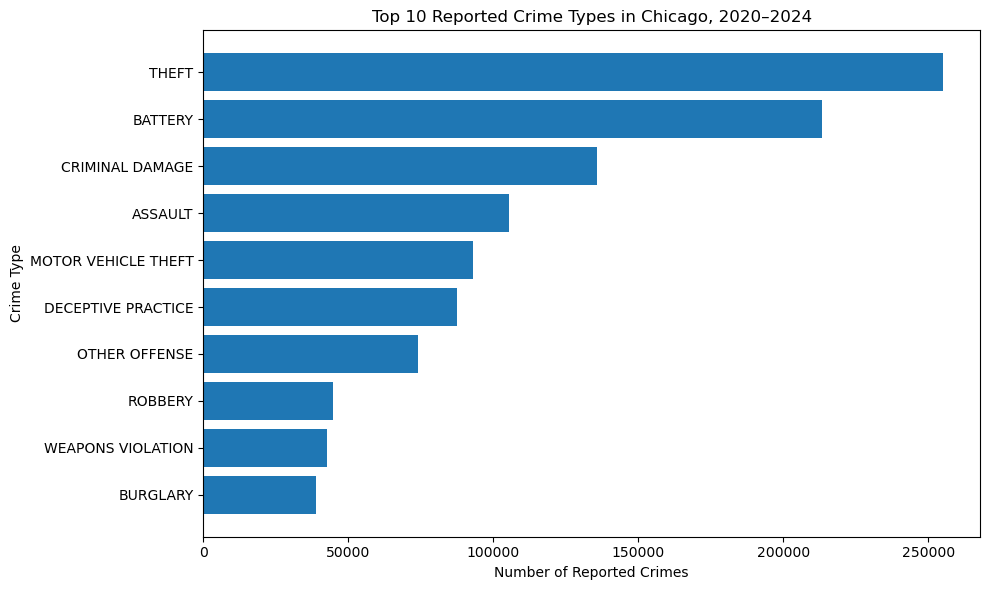

In [27]:
plt.figure(figsize=(10, 6))
plt.barh(

    top_crime_types["primary_type"],

    top_crime_types["crime_count"]

)
plt.gca().invert_yaxis()
plt.xlabel("Number of Reported Crimes")
plt.ylabel("Crime Type")
plt.title("Top 10 Reported Crime Types in Chicago, 2020–2024")
plt.tight_layout()
plt.show()

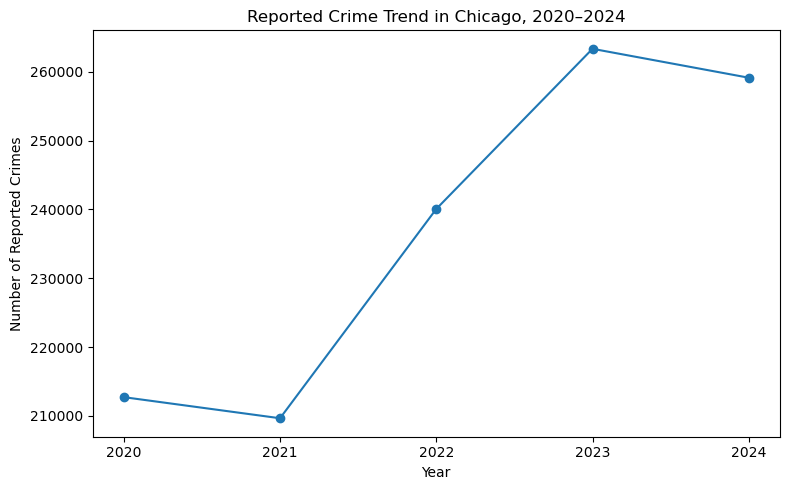

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(

    crime_by_year["year"],

    crime_by_year["total_crimes"],

    marker="o"

)
plt.xlabel("Year")

plt.ylabel("Number of Reported Crimes")

plt.title("Reported Crime Trend in Chicago, 2020–2024")

plt.xticks(crime_by_year["year"])

plt.tight_layout()

plt.show()

The citywide overview shows that reported crime in Chicago is heavily concentrated in a few categories. Theft and battery are the two most common reported crime types, followed by criminal damage, assault, and motor vehicle theft. This suggests that total reported crime volume is shaped by both property-related offenses and violent offenses, so relying only on total crime counts may hide important differences in crime composition.

The yearly trend shows that reported crimes declined slightly from 2020 to 2021, increased sharply in 2022 and 2023, and remained elevated in 2024. This pattern provides citywide context for the analysis, but it does not show whether the increase is evenly distributed across neighborhoods. For that reason, the next sections move from citywide totals to community-area-level variation.

<h3> 5.2 Crime Concentration Across Community Areas </h3>

In [29]:
crime_socio = crime_socio.sort_values(
    "total_crimes",
    ascending=False
).copy()

crime_socio["citywide_crime_share"] = (
    crime_socio["total_crimes"] / crime_socio["total_crimes"].sum()
)

crime_socio["cumulative_crime_share"] = (
    crime_socio["citywide_crime_share"].cumsum()
)

In [30]:
community_concentration = (
    crime_socio[
        [
            "community_area_name",
            "total_crimes",
            "citywide_crime_share",
            "cumulative_crime_share",
            "poverty_rate",
            "per_capita_income",
            "hardship_index"
        ]
    ]
    .sort_values("total_crimes", ascending=False)
    .head(10)
)

community_concentration

,community_area_name,total_crimes,citywide_crime_share,cumulative_crime_share,poverty_rate,per_capita_income,hardship_index
24,Austin,62510,0.052756,0.052756,28.6,15957,73.0
7,Near North Side,49009,0.041362,0.094117,12.9,88669,1.0
27,Near West Side,44421,0.037489,0.131607,20.6,44689,15.0
42,South Shore,40968,0.034575,0.166182,31.1,19398,55.0
31,Loop,36932,0.031169,0.197351,14.7,65526,3.0
28,North Lawndale,34464,0.029086,0.226438,43.1,12034,87.0
23,West Town,34249,0.028905,0.255342,14.7,43198,10.0
22,Humboldt park,32980,0.027834,0.283176,33.9,13781,85.0
70,Auburn Gresham,32221,0.027193,0.310369,27.6,15528,74.0
68,Greater Grand Crossing,30880,0.026061,0.336431,29.6,17285,66.0


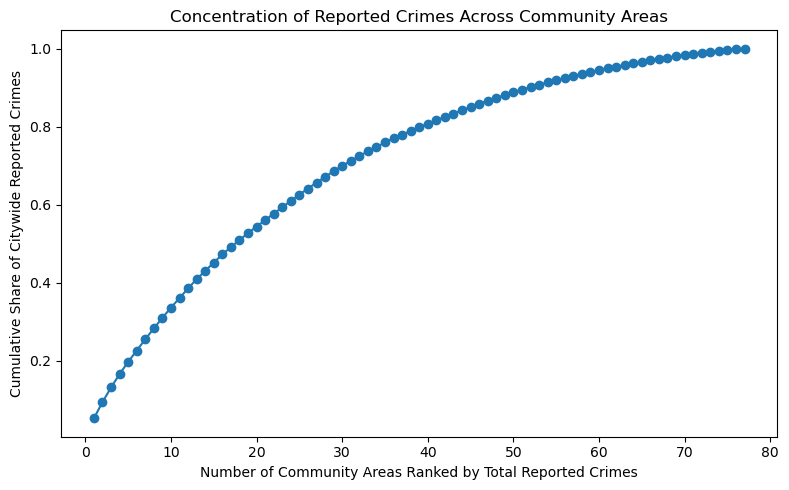

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(

    range(1, len(crime_socio) + 1),

    crime_socio["cumulative_crime_share"],

    marker="o"

)
plt.xlabel("Number of Community Areas Ranked by Total Reported Crimes")

plt.ylabel("Cumulative Share of Citywide Reported Crimes")

plt.title("Concentration of Reported Crimes Across Community Areas")

plt.tight_layout()

plt.show()

The concentration analysis shows that reported crime is not evenly distributed across Chicago’s community areas. A relatively small group of communities accounts for a large share of citywide reported crimes. Austin has the largest individual share, but several high-volume areas, such as the Loop, Near North Side, Near West Side, and West Town, are also major commercial or high-activity areas. This suggests that total reported crime volume may reflect not only neighborhood socioeconomic hardship, but also population exposure, business activity, tourism, and reporting intensity.

The cumulative share curve further supports this point. If reported crimes were evenly distributed, the curve would rise more gradually across all 77 community areas. Instead, the curve rises quickly among the highest-volume communities, indicating concentration. This finding motivates the later analysis of violent crime share and socioeconomic indicators, because total crime volume alone may not fully capture neighborhood safety conditions.

<h3> 5.3 Crime Severity Mix: Total Crime Volume vs Violent Crime Share</h3>

In [32]:
top_violent_share = (
    crime_socio[
        [
            "community_area_name",
            "total_crimes",
            "violent_crimes",
            "violent_crime_share",
            "poverty_rate",
            "per_capita_income",
            "hardship_index"
        ]
    ]
    .sort_values("violent_crime_share", ascending=False)
    .head(10)
)

top_violent_share

,community_area_name,total_crimes,violent_crimes,violent_crime_share,poverty_rate,per_capita_income,hardship_index
53,Riverdale,5948,2510,0.421991,56.5,8201,98.0
67,Englewood,25044,10127,0.404368,46.6,11888,94.0
60,New City,19511,7687,0.393983,29.0,12765,91.0
29,South Lawndale,19502,7669,0.393242,30.7,10402,96.0
28,North Lawndale,34464,13326,0.386664,43.1,12034,87.0
66,West Englewood,24914,9613,0.385847,34.4,11317,89.0
36,Fuller Park,3322,1281,0.385611,51.2,10432,97.0
26,East Garfield Park,19419,7443,0.383284,42.4,12961,83.0
39,Washington Park,11239,4270,0.379927,42.1,13785,88.0
68,Greater Grand Crossing,30880,11693,0.378659,29.6,17285,66.0


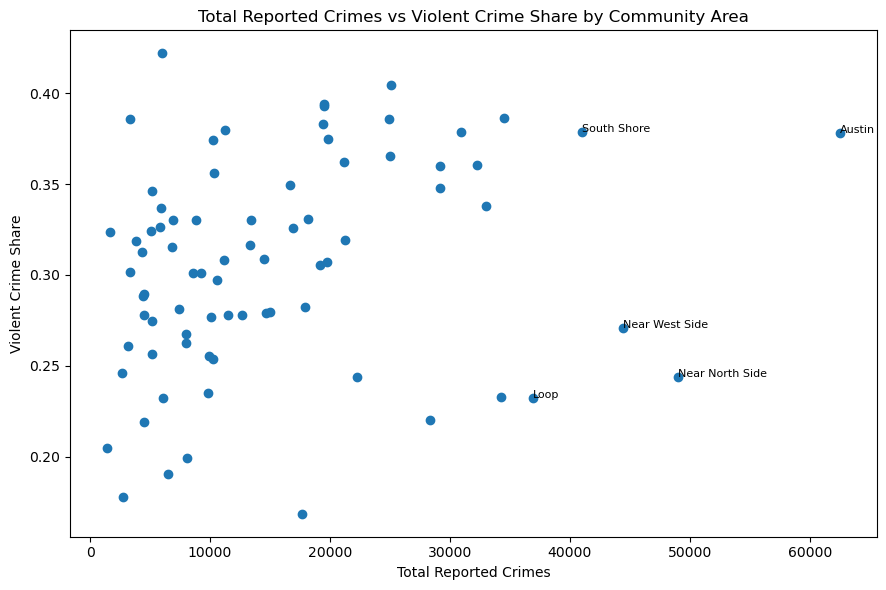

In [33]:
plt.figure(figsize=(9, 6))



plt.scatter(

    crime_socio["total_crimes"],

    crime_socio["violent_crime_share"]

)



for _, row in crime_socio.sort_values("total_crimes", ascending=False).head(5).iterrows():

    plt.text(

        row["total_crimes"],

        row["violent_crime_share"],

        row["community_area_name"],

        fontsize=8

    )



plt.xlabel("Total Reported Crimes")

plt.ylabel("Violent Crime Share")

plt.title("Total Reported Crimes vs Violent Crime Share by Community Area")

plt.tight_layout()

plt.show()

In [34]:
crime_volume_severity_corr = crime_socio["total_crimes"].corr(
    crime_socio["violent_crime_share"]
)

print(f"Correlation between total crimes and violent crime share: {crime_volume_severity_corr:.2f}")

Correlation between total crimes and violent crime share: 0.25


In [35]:
correlation_table = (
    crime_socio[
        [
            "violent_crime_share",
            "domestic_share",
            "arrest_rate",
            "poverty_rate",
            "per_capita_income",
            "hardship_index"
        ]
    ]
    .corr()
    .round(3)
)
correlation_table

,violent_crime_share,domestic_share,arrest_rate,poverty_rate,per_capita_income,hardship_index
violent_crime_share,1.000,0.784,0.432,0.823,-0.745,0.882
domestic_share,0.784,1.000,0.182,0.557,-0.738,0.712
arrest_rate,0.432,0.182,1.000,0.478,-0.311,0.457
poverty_rate,0.823,0.557,0.478,1.000,-0.567,0.803
per_capita_income,-0.745,-0.738,-0.311,-0.567,1.000,-0.849
hardship_index,0.882,0.712,0.457,0.803,-0.849,1.000


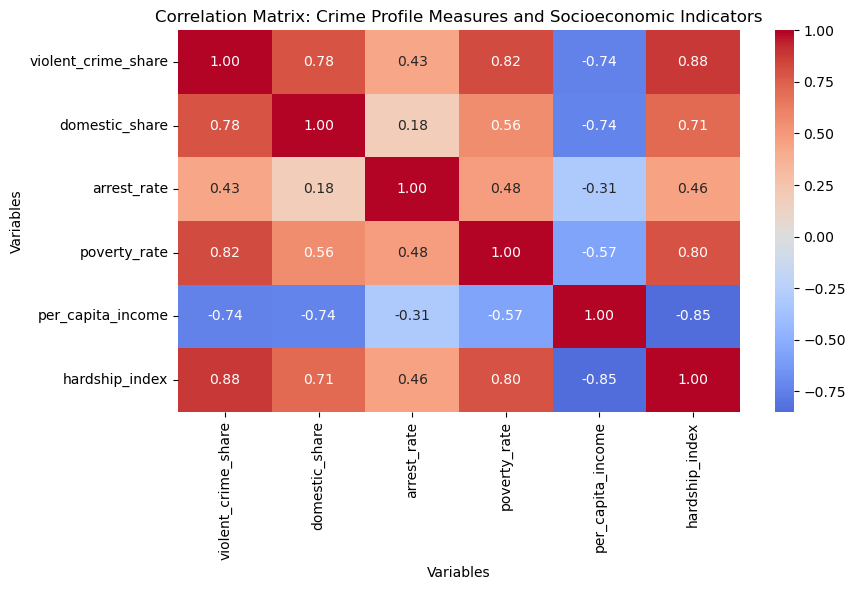

In [36]:
import seaborn as sns
plt.figure(figsize=(9, 6))
sns.heatmap(
    correlation_table,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Correlation Matrix: Crime Profile Measures and Socioeconomic Indicators")
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

The results show that total reported crime volume and violent crime share capture different dimensions of neighborhood safety. The communities with the highest violent crime shares are not always the same as the communities with the highest total crime counts. The correlation between total reported crimes and violent crime share is only 0.25, suggesting that higher crime volume does not necessarily imply a substantially more violent crime profile. For example, high-activity areas such as the Loop, Near North Side, and Near West Side have relatively high reported crime counts but lower violent crime shares, while communities such as Riverdale, Englewood, North Lawndale, and West Englewood have much higher violent crime shares. The correlation matrix further shows that violent crime share is strongly associated with hardship index and poverty rate and negatively associated with per capita income. This supports the idea that socioeconomic conditions are more closely related to crime composition than to total reported crime volume alone. However, these relationships should be interpreted as associations rather than causal effects.

<h3> 5.4 Socioeconomic Segmentation by Hardship Group </h3>

In [37]:
crime_socio["hardship_group"] = pd.qcut(
    crime_socio["hardship_index"],
    q=3,
    labels=["Low hardship", "Medium hardship", "High hardship"]
)

In [38]:
hardship_group_summary = (
    crime_socio
    .groupby("hardship_group", observed=False)
    .agg(
        community_count=("community_area", "count"),
        avg_total_crimes=("total_crimes", "mean"),
        avg_violent_crimes=("violent_crimes", "mean"),
        avg_violent_crime_share=("violent_crime_share", "mean"),
        avg_arrest_rate=("arrest_rate", "mean"),
        avg_domestic_share=("domestic_share", "mean"),
        avg_weekend_share=("weekend_share", "mean"),
        avg_poverty_rate=("poverty_rate", "mean"),
        avg_per_capita_income=("per_capita_income", "mean"),
        avg_hardship_index=("hardship_index", "mean")
    )
    .reset_index()
)

hardship_group_summary

,hardship_group,community_count,avg_total_crimes,avg_violent_crimes,avg_violent_crime_share,avg_arrest_rate,avg_domestic_share,avg_weekend_share,avg_poverty_rate,avg_per_capita_income,avg_hardship_index
0,Low hardship,26,14634.346154,3608.615385,0.244694,0.100150,0.132565,0.276240,12.357692,41554.461538,16.807692
1,Medium hardship,25,13386.880000,4336.560000,0.312179,0.109496,0.216955,0.281543,20.204000,21152.440000,49.520000
2,High hardship,26,18066.423077,6669.307692,0.360356,0.145393,0.238540,0.293371,32.676923,13812.961538,82.192308


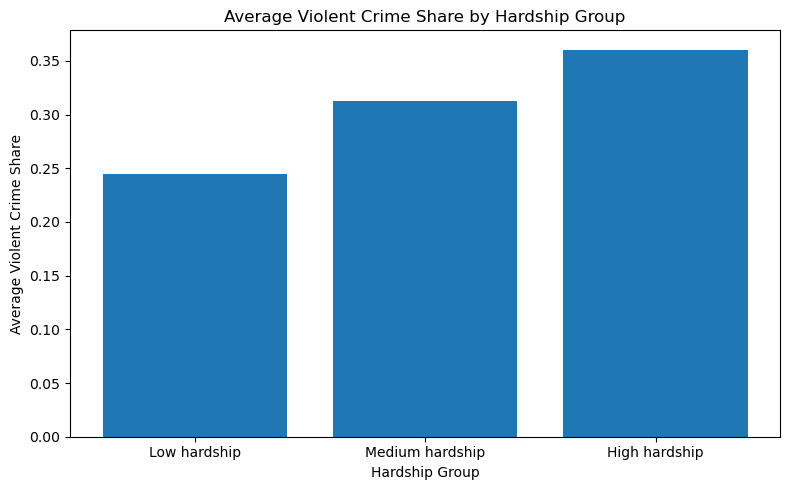

In [39]:
plt.figure(figsize=(8, 5))
plt.bar(

    hardship_group_summary["hardship_group"].astype(str),

    hardship_group_summary["avg_violent_crime_share"]

)
plt.xlabel("Hardship Group")
plt.ylabel("Average Violent Crime Share")
plt.title("Average Violent Crime Share by Hardship Group")
plt.tight_layout()
plt.show()

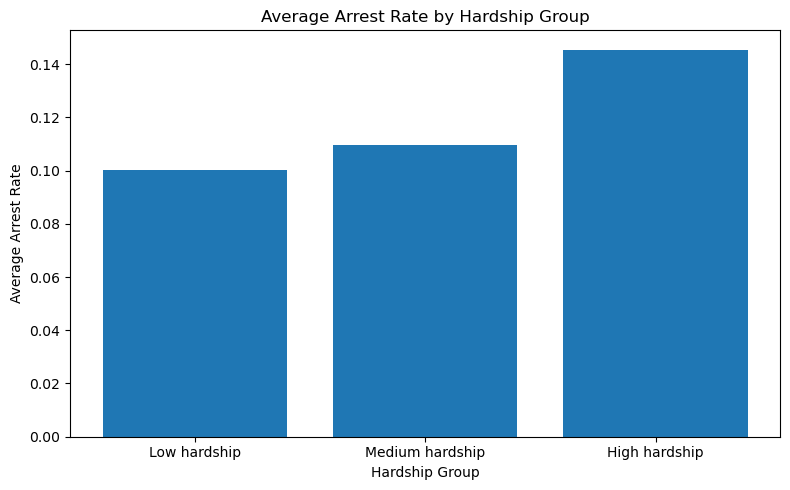

In [40]:
plt.figure(figsize=(8, 5))
plt.bar(

    hardship_group_summary["hardship_group"].astype(str),

    hardship_group_summary["avg_arrest_rate"]

)
plt.xlabel("Hardship Group")

plt.ylabel("Average Arrest Rate")

plt.title("Average Arrest Rate by Hardship Group")

plt.tight_layout()

plt.show()

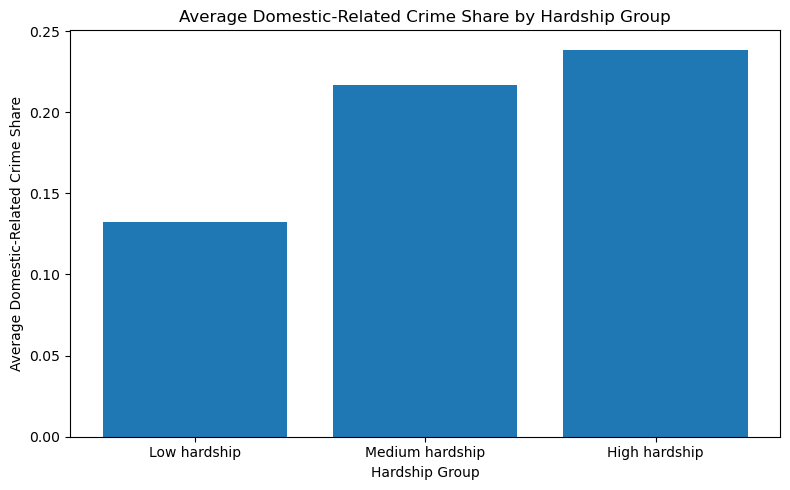

In [43]:
plt.figure(figsize=(8, 5))



plt.bar(

    hardship_group_summary["hardship_group"].astype(str),

    hardship_group_summary["avg_domestic_share"]

)



plt.xlabel("Hardship Group")

plt.ylabel("Average Domestic-Related Crime Share")

plt.title("Average Domestic-Related Crime Share by Hardship Group")

plt.tight_layout()

plt.show()

The hardship-group segmentation shows a clear pattern across socioeconomic conditions. Communities in the high-hardship group have the highest average total reported crimes, the highest average violent crime share, the highest average arrest rate, and the highest average domestic-related crime share. In contrast, the low-hardship group has the lowest average violent crime share and domestic-related crime share. This suggests that socioeconomic hardship is associated not only with higher reported crime volume, but also with a more severe crime composition.

The domestic-related crime share shows a particularly large difference between low-hardship and medium/high-hardship communities, indicating that household- or relationship-related incidents may be more concentrated in communities facing greater socioeconomic stress. The arrest-rate pattern also increases across hardship groups, which may reflect differences in crime type mix, policing activity, or enforcement patterns. These results should not be interpreted causally, but they provide evidence that neighborhood hardship is meaningfully associated with several dimensions of reported crime profiles.

<h3> 5.5 Neighborhood Risk Profile Typology</h3>

In [44]:
crime_socio["high_total_crime"] = (
    crime_socio["total_crimes"] >= crime_socio["total_crimes"].median()
).astype(int)

crime_socio["high_violent_share"] = (
    crime_socio["violent_crime_share"] >= crime_socio["violent_crime_share"].median()
).astype(int)

In [45]:
def assign_risk_profile(row):
    if row["high_total_crime"] == 1 and row["high_violent_share"] == 1:
        return "High volume / High violent share"
    elif row["high_total_crime"] == 1 and row["high_violent_share"] == 0:
        return "High volume / Low violent share"
    elif row["high_total_crime"] == 0 and row["high_violent_share"] == 1:
        return "Low volume / High violent share"
    else:
        return "Low volume / Low violent share"

crime_socio["risk_profile"] = crime_socio.apply(assign_risk_profile, axis=1)

In [46]:
risk_profile_summary = (
    crime_socio
    .groupby("risk_profile")
    .agg(
        community_count=("community_area", "count"),
        avg_total_crimes=("total_crimes", "mean"),
        avg_violent_crimes=("violent_crimes", "mean"),
        avg_violent_crime_share=("violent_crime_share", "mean"),
        avg_arrest_rate=("arrest_rate", "mean"),
        avg_domestic_share=("domestic_share", "mean"),
        avg_poverty_rate=("poverty_rate", "mean"),
        avg_per_capita_income=("per_capita_income", "mean"),
        avg_hardship_index=("hardship_index", "mean")
    )
    .reset_index()
)

risk_profile_summary

,risk_profile,community_count,avg_total_crimes,avg_violent_crimes,avg_violent_crime_share,avg_arrest_rate,avg_domestic_share,avg_poverty_rate,avg_per_capita_income,avg_hardship_index
0,High volume / High violent share,25,24134.000000,8771.960000,0.358415,0.149278,0.247718,30.488000,16004.560000,72.440000
1,High volume / Low violent share,14,24531.785714,6224.642857,0.258743,0.109585,0.113732,16.064286,45172.285714,18.500000
2,Low volume / High violent share,14,6020.071429,2080.142857,0.343080,0.116051,0.229465,28.957143,16397.785714,71.571429
3,Low volume / Low violent share,24,6409.000000,1669.750000,0.256245,0.092944,0.169788,11.812500,29427.875000,30.833333


In [47]:
risk_profile_communities = (
    crime_socio[
        [
            "community_area_name",
            "risk_profile",
            "total_crimes",
            "violent_crime_share",
            "arrest_rate",
            "poverty_rate",
            "per_capita_income",
            "hardship_index"
        ]
    ]
    .sort_values(
        ["risk_profile", "total_crimes"],
        ascending=[True, False]
    )
)

risk_profile_communities.head(20)

,community_area_name,risk_profile,total_crimes,violent_crime_share,arrest_rate,poverty_rate,per_capita_income,hardship_index
24,Austin,High volume / High violent share,62510,0.378211,0.166629,28.6,15957,73.0
42,South Shore,High volume / High violent share,40968,0.378564,0.104691,31.1,19398,55.0
28,North Lawndale,High volume / High violent share,34464,0.386664,0.228818,43.1,12034,87.0
22,Humboldt park,High volume / High violent share,32980,0.337962,0.247271,33.9,13781,85.0
70,Auburn Gresham,High volume / High violent share,32221,0.360324,0.135036,27.6,15528,74.0
68,Greater Grand Crossing,High volume / High violent share,30880,0.378659,0.135525,29.6,17285,66.0
43,Chatham,High volume / High violent share,29184,0.359923,0.127330,27.8,18881,60.0
48,Roseland,High volume / High violent share,29146,0.347938,0.142901,19.8,17949,52.0
67,Englewood,High volume / High violent share,25044,0.404368,0.160837,46.6,11888,94.0
65,Chicago Lawn,High volume / High violent share,25004,0.365462,0.134658,27.9,13231,80.0


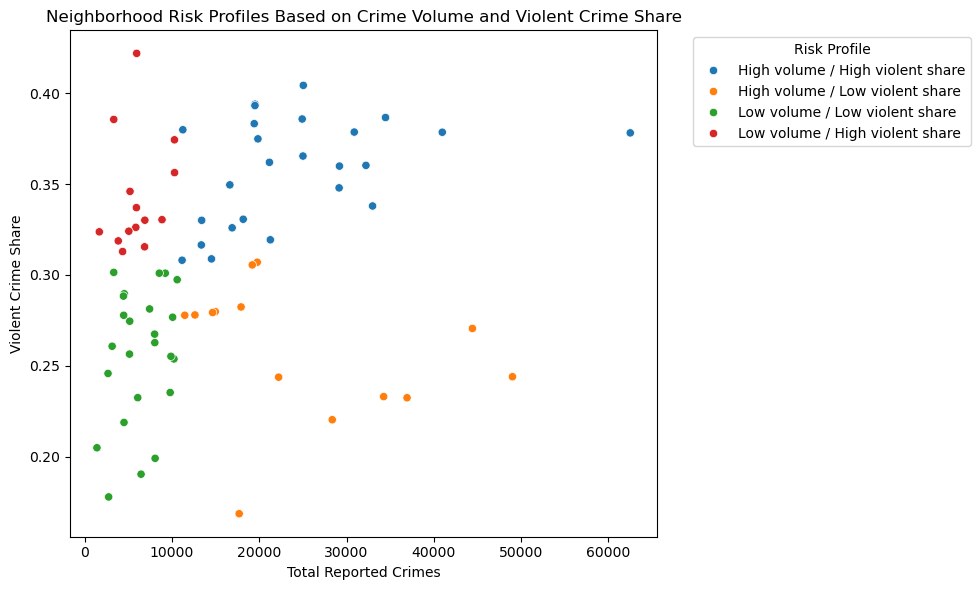

In [48]:
import seaborn as sns



plt.figure(figsize=(10, 6))



sns.scatterplot(

    data=crime_socio,

    x="total_crimes",

    y="violent_crime_share",

    hue="risk_profile"

)



plt.xlabel("Total Reported Crimes")

plt.ylabel("Violent Crime Share")

plt.title("Neighborhood Risk Profiles Based on Crime Volume and Violent Crime Share")

plt.legend(title="Risk Profile", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()

plt.show()

The risk profile typology combines total reported crime volume and violent crime share to classify community areas into four groups. This provides a more nuanced view of neighborhood safety than using total crime counts alone. The “High volume / High violent share” group includes communities with both above-median reported crime volume and above-median violent crime share, suggesting a more severe overall crime profile. In contrast, the “High volume / Low violent share” group includes communities with many reported incidents but a lower violent crime share, which may reflect commercial activity, population exposure, or higher reporting intensity rather than a more violent crime composition.

The “Low volume / High violent share” group is especially important because these communities could be overlooked if the analysis focused only on total reported crimes. Although they have fewer reported incidents overall, a larger share of their incidents are violent. This supports the project’s main argument that neighborhood safety should be evaluated using multiple crime-profile measures. Overall, the typology shows that Chicago community areas differ not only in how many crimes are reported, but also in the severity mix of those reported crimes.

## 5.6 EDA Summary and Implications

The exploratory analysis identifies several important neighborhood-safety patterns in Chicago from 2020 to 2024.

First, reported crime volume changed substantially over time. Total reported incidents were 212,719 in 2020 and 209,654 in 2021, then increased to 240,058 in 2022 and 263,331 in 2023, before remaining elevated at 259,130 in 2024. This citywide trend provides the temporal context for the neighborhood-level analysis.

Second, reported crime is unevenly distributed across community areas. Austin recorded the highest total number of reported incidents, followed by Near North Side, Near West Side, South Shore, and the Loop. However, total crime volume alone does not fully describe neighborhood safety. Some high-volume communities have relatively lower violent-crime shares, while others combine high crime volume with a high violent-crime share.

Third, socioeconomic hardship is strongly associated with crime composition. In the hardship segmentation, average violent-crime share increases from approximately 24.5% in low-hardship communities to 36.0% in high-hardship communities. Domestic-related crime share follows a similar pattern, rising from about 13.3% to 23.9% across the same groups. This suggests that hardship is associated not only with the amount of reported crime, but also with the type of reported crime.

Finally, the correlation analysis reinforces these patterns. Violent-crime share is positively associated with hardship index (0.882), poverty rate (0.823), domestic-related crime share (0.784), and arrest rate (0.432), and negatively associated with per capita income (-0.745). These findings support using socioeconomic indicators in the modeling stage to examine variation in neighborhood crime profiles. The results remain descriptive and should be interpreted as associations rather than causal effects.

<h2> 6. Modeling: Socioeconomic Indicators and Crime Profile Measures</h2>

<h3>6.1 Model Setup </h3>

To satisfy the modeling requirement that engineered features are included in model inputs, we create three additional predictors from the socioeconomic variables. These engineered features improve interpretability and allow the models to capture non-linear scale effects and interaction effects.

- `income_10k`: per capita income scaled to 10,000-dollar units for easier coefficient interpretation
- `log_income`: log-transformed income to reduce extreme high-income influence
- `poverty_hardship_interaction`: interaction term that captures compounded socioeconomic disadvantage when both poverty and hardship are high

In [49]:
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [50]:
crime_socio["income_10k"] = crime_socio["per_capita_income"] / 10000
crime_socio["log_income"] = np.log1p(crime_socio["per_capita_income"])
crime_socio["poverty_hardship_interaction"] = (
    crime_socio["poverty_rate"] * crime_socio["hardship_index"])
crime_socio[
    [
        "community_area_name",
        "per_capita_income",
        "income_10k",
        "log_income",
        "poverty_hardship_interaction"
    ]
].head()

,community_area_name,per_capita_income,income_10k,log_income,poverty_hardship_interaction
24,Austin,15957,1.5957,9.677716,2087.8
7,Near North Side,88669,8.8669,11.392677,12.9
27,Near West Side,44689,4.4689,10.707505,309.0
42,South Shore,19398,1.9398,9.872977,1710.5
31,Loop,65526,6.5526,11.090218,44.1


**Engineered Feature Rationale**

| New Feature | Definition | Why It Helps |
|---|---|---|
| `income_10k` | `per_capita_income / 10000` | Rescales income so coefficients are easier to read and compare. |
| `log_income` | `log(1 + per_capita_income)` | Reduces skew from high-income communities and stabilizes linear fit. |
| `poverty_hardship_interaction` | `poverty_rate * hardship_index` | Captures compounded disadvantage when poverty and hardship are simultaneously high. |

In [51]:
model_data = crime_socio.dropna(subset=[

    "violent_crime_share",

    "domestic_share",

    "poverty_rate",

    "per_capita_income",

    "hardship_index",

    "income_10k",

    "log_income",

    "poverty_hardship_interaction"

]).copy()



model_features = [

    "poverty_rate",

    "per_capita_income",

    "hardship_index",

    "income_10k",

    "log_income",

    "poverty_hardship_interaction"

]



model_data.shape

(77, 21)

<h3> 6.2 Model 1: Predicting Violent Crime Share </h3>

In [52]:
model_data = crime_socio.dropna(

    subset=[

        "violent_crime_share",

        "poverty_rate",

        "log_income",

        "poverty_hardship_interaction"

    ]

).copy()



model_features = [

    "poverty_rate",

    "log_income",

    "poverty_hardship_interaction"

]



X = model_data[model_features]

y = model_data["violent_crime_share"]



X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.25,

    random_state=42

)



violent_model = Pipeline([

    ("scaler", StandardScaler()),

    ("regression", LinearRegression())

])



violent_model.fit(X_train, y_train)

violent_pred = violent_model.predict(X_test)

In [53]:
violent_model_metrics = pd.DataFrame({

    "Metric": ["R-squared", "MAE", "RMSE"],

    "Value": [

        r2_score(y_test, violent_pred),

        mean_absolute_error(y_test, violent_pred),

        mean_squared_error(y_test, violent_pred) ** 0.5

    ]

}).round(4)



violent_model_metrics

,Metric,Value
0,R-squared,0.8719
1,MAE,0.0148
2,RMSE,0.0191


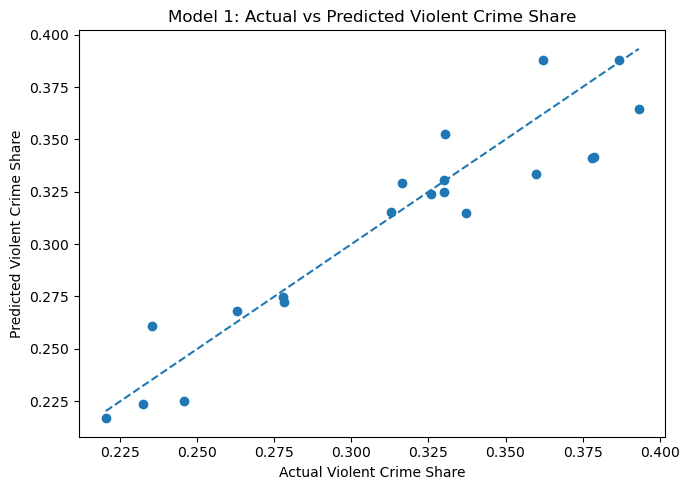

In [54]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, violent_pred)



plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    linestyle="--"

)



plt.xlabel("Actual Violent Crime Share")

plt.ylabel("Predicted Violent Crime Share")

plt.title("Model 1: Actual vs Predicted Violent Crime Share")

plt.tight_layout()

plt.show()

In [55]:
violent_model_coef = pd.DataFrame({

    "feature": model_features,

    "coefficient": violent_model.named_steps["regression"].coef_

})



violent_model_coef

,feature,coefficient
0,poverty_rate,0.045447
1,log_income,-0.035698
2,poverty_hardship_interaction,-0.023339


Model 1 shows that socioeconomic indicators explain a large share of the variation in violent crime share across Chicago community areas. The model achieves an R-squared of 0.8719, with an MAE of 0.0148 and an RMSE of 0.0191, suggesting that the model’s predicted violent crime shares are relatively close to the actual community-level values. The coefficient signs are broadly consistent with the EDA: poverty is positively associated with violent crime share, while log income is negatively associated with violent crime share. Because the predictors are scaled before regression, the coefficients should be interpreted as relative directional effects rather than raw unit changes.

<h3> 6.3 Model 2: Predicting Domestic-Related Crime Share </h3>

In [57]:
domestic_model_data = crime_socio.dropna(

    subset=[

        "domestic_share",

        "poverty_rate",

        "log_income",

        "poverty_hardship_interaction"

    ]

).copy()



X = domestic_model_data[model_features]

y = domestic_model_data["domestic_share"]



X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.25,

    random_state=42

)



domestic_model = Pipeline([

    ("scaler", StandardScaler()),

    ("regression", LinearRegression())

])



domestic_model.fit(X_train, y_train)

domestic_pred = domestic_model.predict(X_test)

In [58]:
domestic_model_metrics = pd.DataFrame({

    "Metric": ["R-squared", "MAE", "RMSE"],

    "Value": [

        r2_score(y_test, domestic_pred),

        mean_absolute_error(y_test, domestic_pred),

        mean_squared_error(y_test, domestic_pred) ** 0.5

    ]

}).round(4)



domestic_model_metrics

,Metric,Value
0,R-squared,0.5778
1,MAE,0.0365
2,RMSE,0.0420


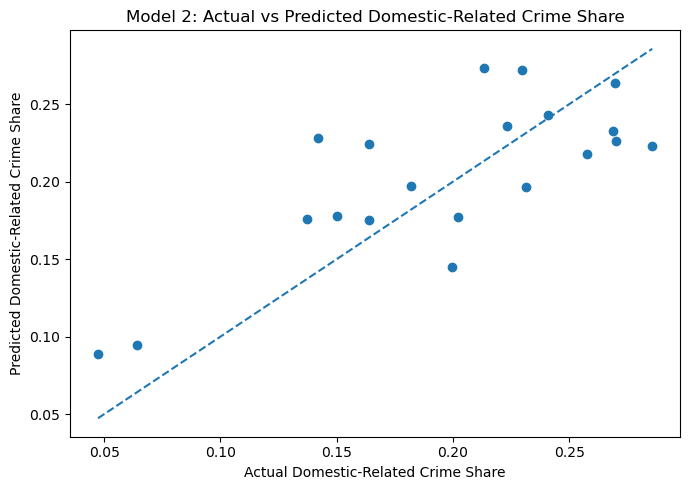

In [59]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, domestic_pred)



plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    linestyle="--"

)



plt.xlabel("Actual Domestic-Related Crime Share")

plt.ylabel("Predicted Domestic-Related Crime Share")

plt.title("Model 2: Actual vs Predicted Domestic-Related Crime Share")

plt.tight_layout()

plt.show()

In [60]:
domestic_model_coef = pd.DataFrame({

    "feature": model_features,

    "coefficient": domestic_model.named_steps["regression"].coef_

})



domestic_model_coef

,feature,coefficient
0,poverty_rate,0.010378
1,log_income,-0.052004
2,poverty_hardship_interaction,-0.008751


Model 2 predicts domestic-related crime share using the same socioeconomic predictors. The model has an R-squared of 0.5778, which is lower than the violent crime share model but still indicates meaningful explanatory value. This suggests that socioeconomic conditions are associated with domestic-related crime composition, though the relationship is less tightly captured by the current predictors than the violent crime share model. As with Model 1, the results should be interpreted as descriptive associations rather than causal effects.

<h3> 6.4 Model Summary and Limitation </h3>

The two linear regression models evaluate whether neighborhood socioeconomic conditions are associated with differences in crime composition across Chicago community areas.

Model 1 predicts violent crime share using poverty rate, log-transformed income, and an engineered interaction term between poverty rate and hardship index. In this dataset, the model indicates that socioeconomic indicators provide substantial explanatory value for neighborhood-level variation in violent crime share.

Model 2 predicts domestic-related crime share using the same explanatory variables. This extends the analysis beyond total crime and violent crime by testing whether socioeconomic hardship is also linked to variation in domestic-related incident composition across neighborhoods.

Several limitations should be noted. First, the modeling dataset includes only 77 community areas, so results are sensitive to individual neighborhoods and should be interpreted cautiously. Second, the analysis uses reported crime rather than all actual crime, which means reporting behavior and policing practices may affect observed patterns. Third, the models estimate statistical associations rather than causal effects. Finally, the current specification does not control for neighborhood population, daytime population, commercial activity, or housing density, all of which may influence reported crime levels and crime shares.

<h2> 7. Conclusion and Future Work </h2>

<h3> 7.1 Conclusion and Implication</h3>

This project shows that neighborhood safety patterns in Chicago from 2020 to 2024 are not captured by total crime counts alone. Reported crime volume increased after 2021 and remained elevated through 2024, while community-level risk profiles varied meaningfully in both scale and composition.

Across EDA and modeling, socioeconomic context is consistently associated with crime composition. Communities with higher hardship and poverty generally show higher violent-crime shares, while higher per capita income is associated with lower violent-crime share. The domestic-related crime model also indicates that socioeconomic conditions are related to broader crime composition, not only violent incidents.

For policy and planning audiences, the main implication is that neighborhood safety strategies should be multi-dimensional: volume-focused interventions should be complemented by composition-focused responses in communities where violent and domestic-related shares are disproportionately high.

<h3> 7.2 Limitations </h3>

Several limitations affect interpretation. The analysis is cross-sectional at the community-area level after aggregation, and the modeling sample includes only 77 communities, which limits statistical power and makes estimates sensitive to individual neighborhoods.

The study uses reported crime rather than all actual incidents, so observed patterns may be influenced by reporting behavior, policing activity, and administrative recording practices. In addition, the current models focus on a limited set of socioeconomic predictors and do not explicitly control for population exposure, daytime population, land use intensity, housing density, or mobility patterns.

Most importantly, the findings represent statistical associations and should not be interpreted as causal effects.

<h3> 7.3 Future Work </h3>

If more time and data were available, several extensions would strengthen this analysis.

1. Add population-normalized outcomes (for example, crimes per 1,000 residents) and daytime-population adjustments to improve comparability across communities.
2. Incorporate additional datasets, such as housing vacancy, business density, transit access, school context, and 311/service indicators, to better capture neighborhood conditions.
3. Expand modeling with time-aware structures (panel or year-by-community models), regularization, and robust validation to test stability of coefficients across years.
4. Evaluate non-linear and interaction-heavy methods while preserving interpretability through feature importance and partial dependence summaries.
5. Compare policy-targeting scenarios that prioritize high-volume communities versus high-severity communities to support practical decision-making.